## Big Project for PDFA module
Author Cathal Redmond
Date 22 Dec 2025. (Ho Ho Ho.)


In [87]:
## Big Project 
## I am opting to do the suggested wind farm data analysis project.
## I will select the closest data set to my location in Enniscorthy Co. Wexford, which is the Johnstown Castle data set.


In [88]:
##imports
import numpy as np
import pandas as pd
from io import BytesIO
from zipfile import ZipFile
import requests



In [89]:
# define a function to download and extract data from Met Eireann historical data website
def download_data():
    url = "https://cli.fusio.net/cli/climate_data/webdata/hly1775.zip"
    r = requests.get(url)
    zip_ref = ZipFile(BytesIO(r.content))
    
    dataframes = []
    
    for name in zip_ref.namelist():
        if name.endswith('.csv'):  # Only process CSV files
            print(f"Processing {name}")
            with zip_ref.open(name) as file_contents:
                df = pd.read_csv(file_contents, delimiter=',', skiprows=13, header=3, on_bad_lines='skip')
                dataframes.append(df)
    
    # Concatenate all dataframes into one
    if dataframes:
        combined_df = pd.concat(dataframes, ignore_index=True)
    else:
        combined_df = pd.DataFrame()
    
    print("Data loaded into DataFrame successfully")
    return combined_df

# place the data into a dataframe
# this will be useful as we will need to work with the data. 

dfjohnstown = download_data()
print(dfjohnstown.head())

Processing hly1775.csv
Data loaded into DataFrame successfully
                date  ind rain  ind.1 temp  ind.2 wetb dewpt vappr rhum msl  \
0  12-aug-2003 01:00   -1           4           4                             
1  12-aug-2003 02:00   -1           4           4                             
2  12-aug-2003 03:00   -1           4           4                             
3  12-aug-2003 04:00   -1           4           4                             
4  12-aug-2003 05:00   -1           4           4                             

   ind.3 wdsp  ind.4 wddir  
0      7           7        
1      7           7        
2      7           7        
3      7           7        
4      7           7        


/tmp/ipykernel_62753/4057818524.py:13: DtypeWarning: Columns (2,4,6,7,8,9,10,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_contents, delimiter=',', skiprows=13, header=3, on_bad_lines='skip')


In [90]:
# calculate basic statistics on the wind speed column
wind_speed = pd.to_numeric(dfjohnstown['wdsp'], errors='coerce')  #convert to numeric, coerce errors to NaN
mean_wind_speed = wind_speed.mean()
max_wind_speed = wind_speed.max()
min_wind_speed = wind_speed.min()
print(f"Mean Wind Speed: {mean_wind_speed} Knots")
print(f"Max Wind Speed: {max_wind_speed} Knots")
print(f"Min Wind Speed: {min_wind_speed} Knots")

Mean Wind Speed: 8.119892871095757 Knots
Max Wind Speed: 35.0 Knots
Min Wind Speed: 0.0 Knots


In [91]:
# calculate average wind speeds for each month, day and hour
dfjohnstown['wdsp'] = pd.to_numeric(dfjohnstown['wdsp'], errors='coerce')
dfjohnstown['date'] = pd.to_datetime(dfjohnstown['date'], format='%d-%b-%Y %H:%M')
dfjohnstown.set_index('date', inplace=True)
monthly_avg_wind = dfjohnstown['wdsp'].resample('ME').mean()
daily_avg_wind = dfjohnstown['wdsp'].resample('D').mean()
hourly_avg_wind = dfjohnstown['wdsp'].resample('h').mean()  


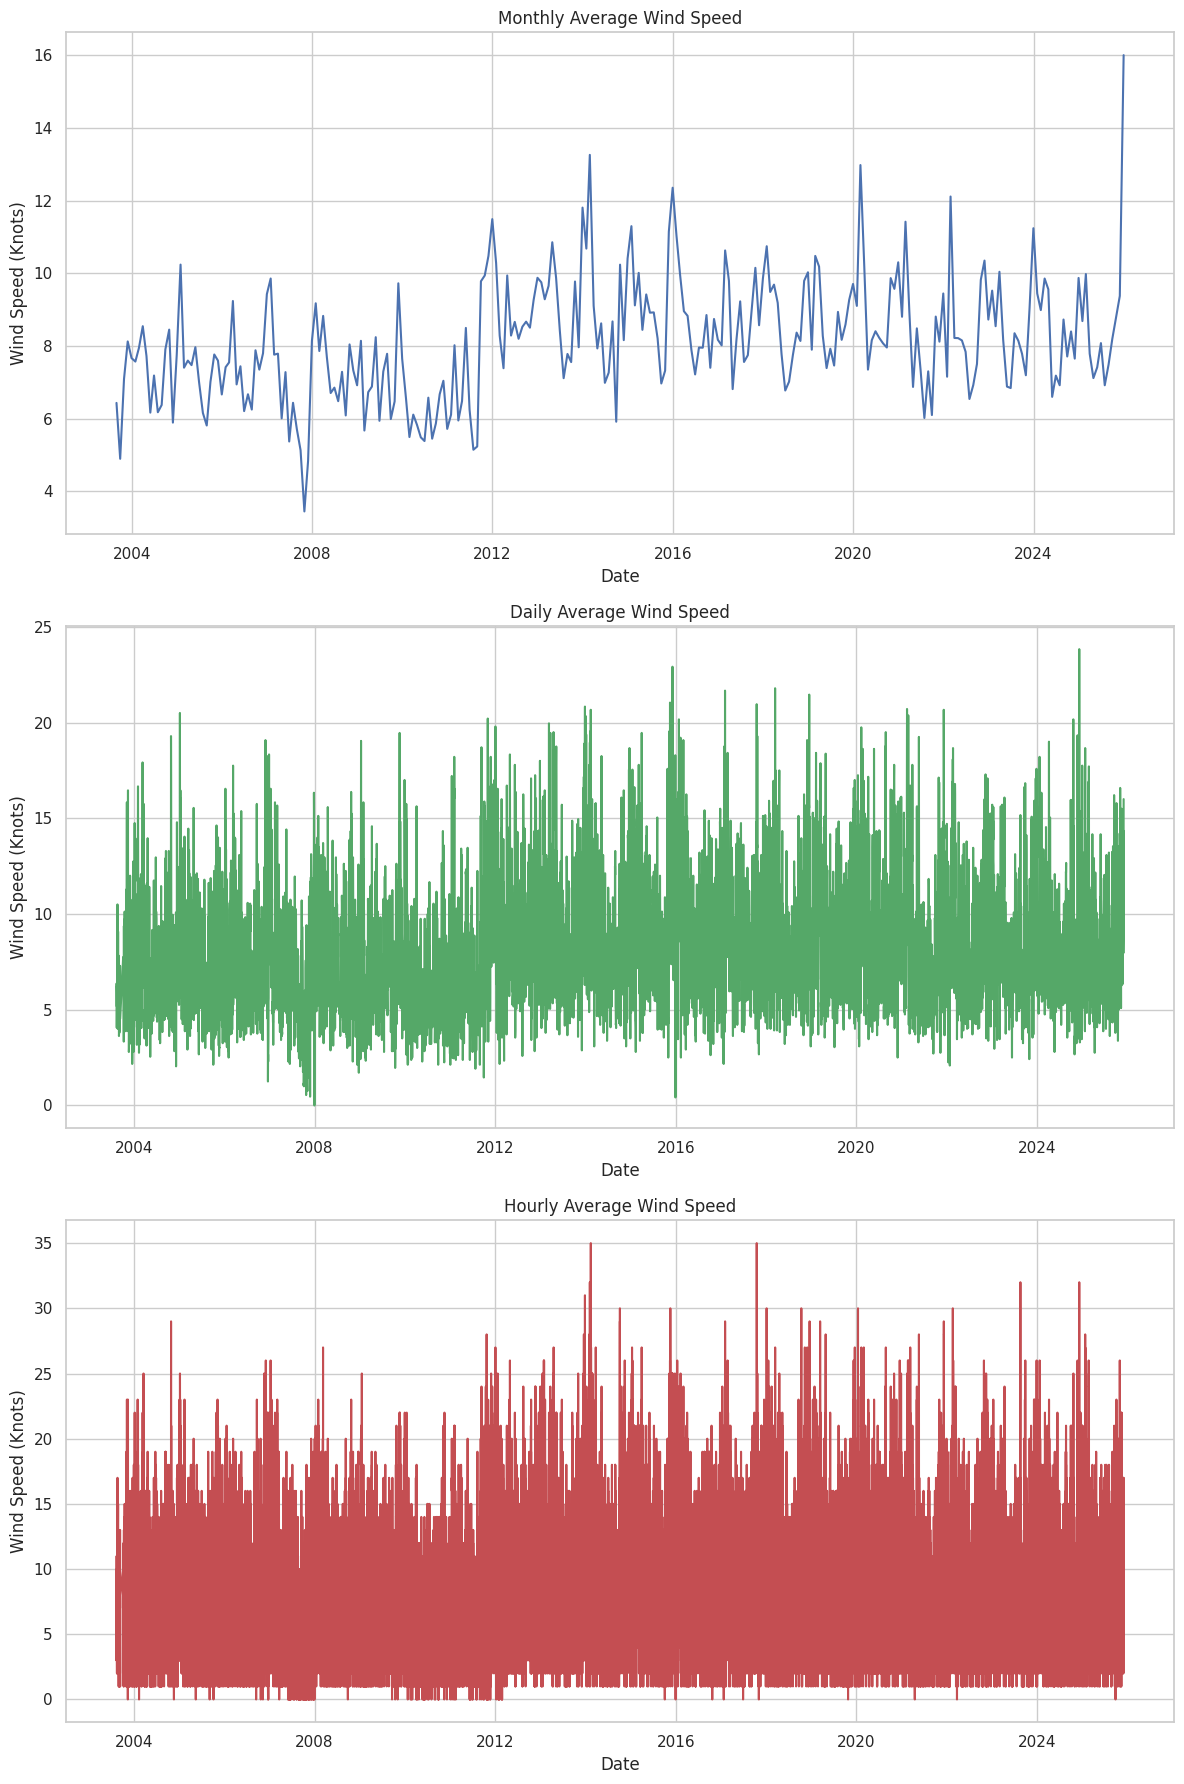

In [92]:
# plot the average wind speeds using seaborn using three subplots for monthly, daily and hourly averages

import seaborn as sns 
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

sns.lineplot(data=monthly_avg_wind, ax=axes[0], color='b')
axes[0].set_title('Monthly Average Wind Speed')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Wind Speed (Knots)')

sns.lineplot(data=daily_avg_wind, ax=axes[1], color='g')
axes[1].set_title('Daily Average Wind Speed')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Wind Speed (Knots)')

sns.lineplot(data=hourly_avg_wind, ax=axes[2], color='r')
axes[2].set_title('Hourly Average Wind Speed')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Wind Speed (Knots)')

plt.tight_layout()
plt.show()

#print(f"Monthly Average Wind Speeds:{monthly_avg_wind}")
#print(f"Daily Average Wind Speeds:{daily_avg_wind}")
#print(f"Hourly Average Wind Speeds:{hourly_avg_wind}")

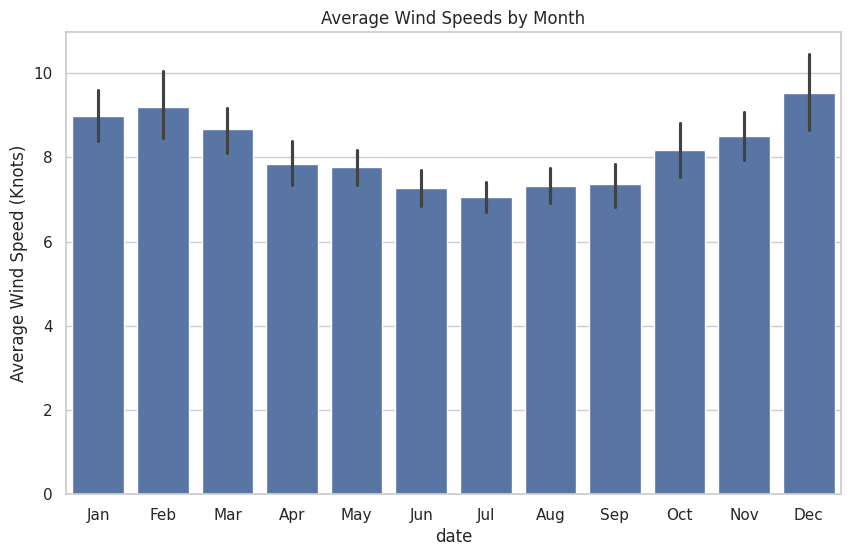

In [93]:
# show a barchart of the average wind speeds for each month
plt.figure(figsize=(10,6))
sns.barplot(x=monthly_avg_wind.index.month, y=monthly_avg_wind.values, color='b')
plt.title('Average Wind Speeds by Month')
plt.xticks(range(0,12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.ylabel('Average Wind Speed (Knots)')
plt.show()


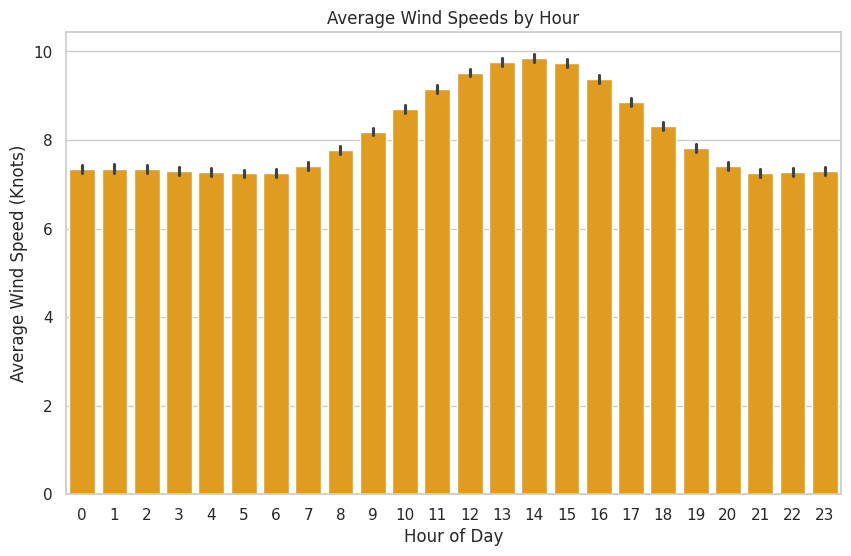

In [94]:
# show a barchart of the average wind speeds for each hour
plt.figure(figsize=(10,6))
sns.barplot(x=hourly_avg_wind.index.hour, y=hourly_avg_wind.values, color='orange')
plt.title('Average Wind Speeds by Hour')
plt.xticks(range(0,24), [str(i) for i in range(0,24)])
plt.ylabel('Average Wind Speed (Knots)')
plt.xlabel('Hour of Day')
plt.show()

* OK so i dont believe this graph is correct - i would not expect the hourly average wind to be as orderly as this, showing basically flat line between 9pm and 6am, and then a gradual increase to a peak at 2pm, and then gradual decline to 9pm again. 
* This looks much more like something related to daylight hours - possibly even might coincide with office hours - indicating a human record-keeping bias towards these times. 
* Investigate whether this is an artefact of the average sampling fucntion, by plotting the same graph from the raw data. 

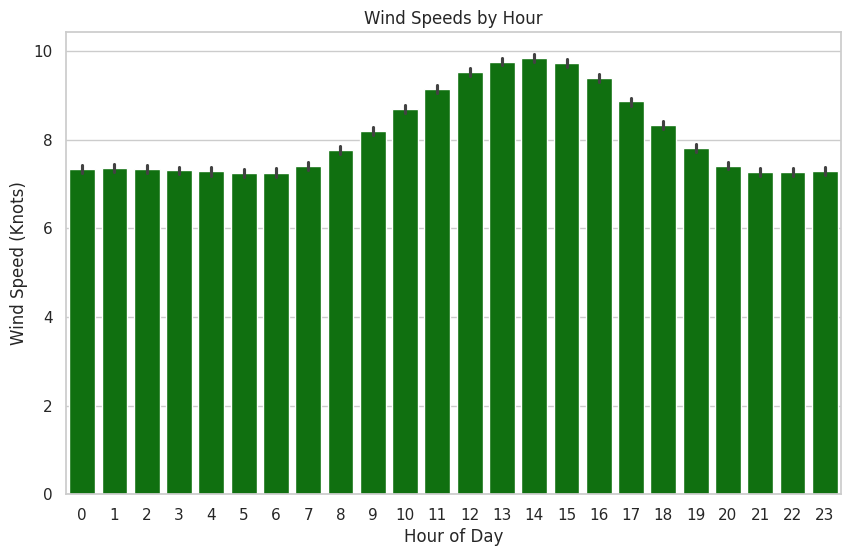

In [95]:
# show a barchart of the wind speeds for each hour
plt.figure(figsize=(10,6))
sns.barplot(x=dfjohnstown.index.hour, y=dfjohnstown['wdsp'], color='green')
plt.title('Wind Speeds by Hour')
plt.xticks(range(0,24), [str(i) for i in range(0,24)])
plt.ylabel('Wind Speed (Knots)')
plt.xlabel('Hour of Day')
plt.show()

Astonishigly, it seems the same pattern persists. 
* I have done some quick googling to see if there is an explanation for this observation, and it seems that there is a generalisable rule that afternoon time does seem to have higher windspeeds on average, due to the day starting out cooler and the air heating up as the sun warms the land throughout the day. This is highly dependant on local topography - Johnstown observation station in Wexford being costal may influence this. 
* Reference for this: Hartman, A.T. An analysis of the effects of temperatures and circulations on the strength of the low-level jet in the Turkana Channel in East Africa. Theor Appl Climatol 132, 1003–1017 (2018). https://doi.org/10.1007/s00704-017-2121-x

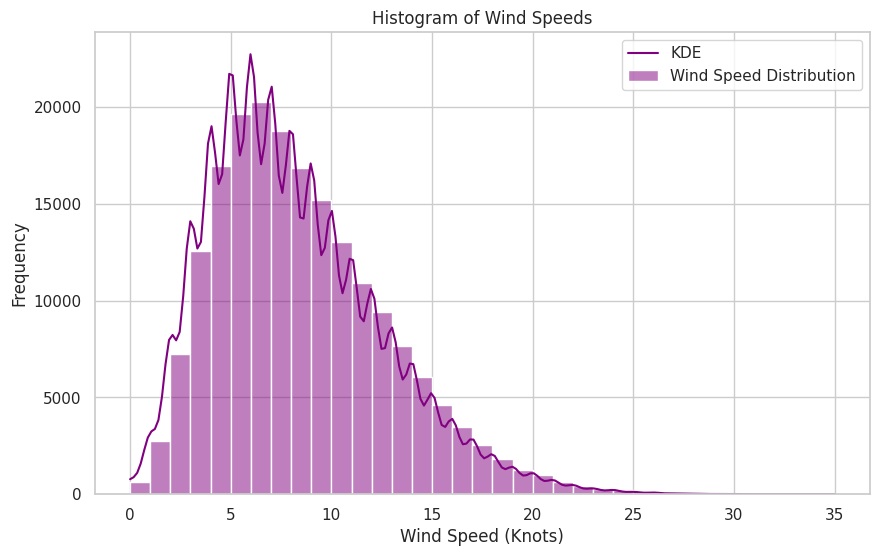

In [96]:
# Show histrogram of wind speeds for hourly average wind speed values. 
plt.figure(figsize=(10,6))
sns.histplot(dfjohnstown['wdsp'].dropna(), bins=35, kde=True, color='purple', stat = 'frequency')

plt.title('Histogram of Wind Speeds')
plt.xlabel('Wind Speed (Knots)')
plt.ylabel('Frequency')
plt.legend(['KDE','Wind Speed Distribution','Percentage of Occurances'])
plt.show()  

From this histogram chart we can extract a number of valuable insights. 
* Firstly, we can see the data follows a Right-Skewed histogram shape with its peak occuring at approximatelty 8 knots, indicating that the most frequently detected observation occurs at this wind speed. This will be a useful parameter when selecting the specific type of wind turbine for this location, as turbine selection is based largely on wind speed and consistency. 
* Approximately 85% of the observations were between 4 knots and 15 knots. 
* We see there are relatively fewer observations below 4 knots ~ 5%, and above 15 knots ~ 10%. 


* Note: we can see there is a Saw-tooth pattern visible in the Kernel Density Estimation line, which is an artefact of the data being sampled in integer values only. This can limit the usefulness of the data, as the frequency of windspeeds between each whole-number value are estimated to be lower than their likely physical occurance. 

In [97]:
# Quantifying Wind Variability. 
# Wind variability can be quantified using statistical measures such as standard deviation and coefficient of variation (CV).
# https://energy.sustainability-directory.com/term/wind-variability/#:~:text=Coefficient%20of%20Variation%20(CoV)%20%E2%86%92%20The%20CoV%2C,different%20locations%20with%20varying%20average%20wind%20speeds.

# Calculate standard deviation of wind speeds
std_dev = dfjohnstown['wdsp'].std()
print(f"Standard Deviation of Wind Speeds: {std_dev}")

# Calculate coefficient of variation (CV) 
cv = (std_dev / dfjohnstown['wdsp'].mean()) * 100
print(f"Coefficient of Variation: {cv}%")


Standard Deviation of Wind Speeds: 4.275873586007992
Coefficient of Variation: 52.65923644422386%


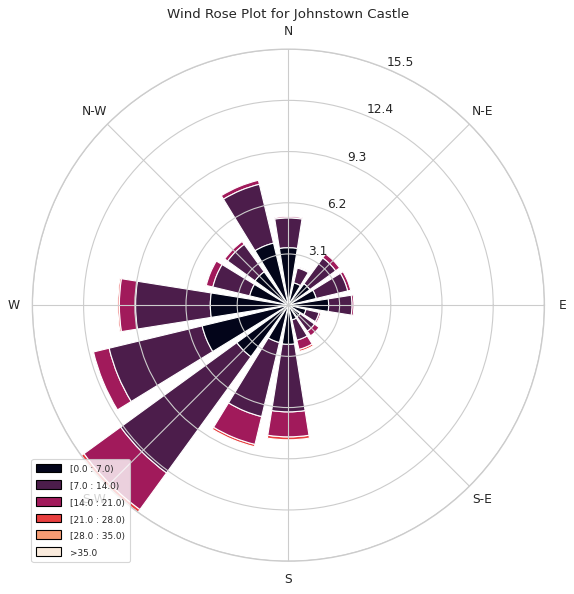

In [98]:
# generate wind rose plot to visualise wind direction and speed distribution
dfjohnstown['wddir'] = pd.to_numeric(dfjohnstown['wddir'], errors='coerce')
from windrose import WindroseAxes
ax = WindroseAxes.from_ax()
ax.bar(dfjohnstown['wddir'], dfjohnstown['wdsp'], normed=True, opening=0.8, edgecolor='white')
ax.set_title('Wind Rose Plot for Johnstown Castle')
ax.set_legend()
plt.show()

## End of code